## The purpose of this experiment to answer these questions
- Can i predict the mask from any new H pose camera?
- The prediction will be better?
- Can i reveal the iddent state sigms?
- Can i reveal the depth map?

## Part 5 Train (neglict ci)

## import libraries

In [1]:

from __future__ import annotations
from pathlib import Path
from typing import List
import platform
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt

# nerflab imports (make sure your env has nerflab on PYTHONPATH)
from nerflab import Intrinsics, Camera, CFG, load_world, plot_world
from nerflab.io import load_batch_simple, discover_cfg_hash, get_frame_ids_for_case
from nerflab.viz.render import Renderer, BinaryRenderCfg
from nerflab.viz.plot_nonzero_sigma import plot_nonzero_sigma_row
from nerflab.viz.viz_sigma import viz_sigma_heatmap, viz_sigma_scatter  # adjust import if needed

from torch import nn
from torch.nn.modules import Module
from torch.nn.functional import mse_loss
from torch.optim import SGD
from torch.nn import Sequential, Linear, Softplus

from nerflab.nerf_sigma_learning.ops.forward_sigma import nerf_opacity, compute_opacity_simple
from nerflab.nerf_sigma_learning.learning_utils.layer_probe import LayerProbe


In [2]:
# gpu_check.py

print(f"PyTorch           : {torch.__version__}")
print(f"Python            : {platform.python_version()} ({sys.executable})")
print(f"CUDA available    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA toolkit ver. : {torch.version.cuda}")
    print(f"CuDNN ver.        : {torch.backends.cudnn.version()}")
    print(f"GPU count         : {torch.cuda.device_count()}")
    for idx in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(idx)
        print(f"  · Device {idx}: {props.name} "
              f"({props.total_memory/1024**3:.1f} GB, "
              f"Compute {props.major}.{props.minor})")
else:
    print("→  No CUDA GPU detected by PyTorch.")


PyTorch           : 2.7.1+cu128
Python            : 3.10.12 (/home/elyamani/Main/programming/nerf-lab/.venv/bin/python)
CUDA available    : True
CUDA toolkit ver. : 12.8
CuDNN ver.        : 90701
GPU count         : 1
  · Device 0: NVIDIA GeForce RTX 4050 Laptop GPU (5.6 GB, Compute 8.9)


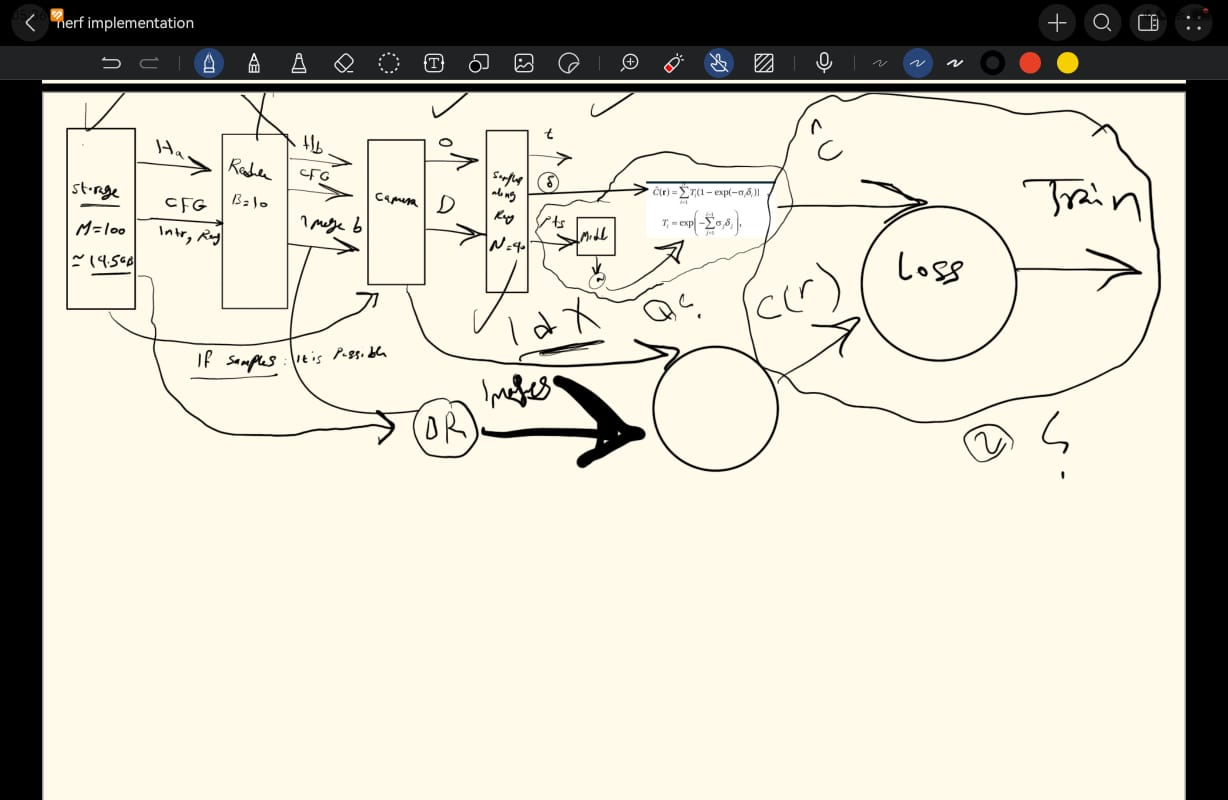

In [3]:

# ---- Parameters (edit these) ----
scene_dir = Path("../../data/data_experiment1")  # root scene directory
split = "train"                   # one of: "train", "val", "test"
seed = 7
cfg_hash = None                  # if None, auto-discover from cache folder
num_frames = 100
frame_offset = 0
device = "cpu"                   # set "cuda" if available
show_world = True               # set True to plot the world and selected camera
world_json_path = "../data/world.json"  # update if your world.json lives elsewhere
# K = CFG.rays.R
K = 1024
torch.manual_seed(seed)

In [4]:
# ---- Discover cfg_hash and list NPZ frames ----
_cfg = cfg_hash or discover_cfg_hash(scene_dir, split)


In [5]:
frame_ids, cfg_used = get_frame_ids_for_case(
    scene_dir, split,
    seed=seed,
    cfg_hash=cfg_hash,
    num_frames=num_frames,
    frame_offset=frame_offset,
)
print(f"Total data frames: {len(frame_ids)}")


Total data frames: 100


In [6]:
batch = load_batch_simple(scene_dir, frame_ids)

In [7]:
print("=== Batch Summary ===")
print(f" Width         : {batch['width']}")
print(f" Height        : {batch['height']}")
print(f" #Frame IDs    : {len(batch['frame_ids'])}")
print(f" #Image paths  : {len(batch['image_paths'])}")
print(f" Images shape  : {batch['images'].shape}")
print(f" H_wc shape    : {batch['H_wc'].shape}")
print("======================")


=== Batch Summary ===
 Width         : 640
 Height        : 480
 #Frame IDs    : 100
 #Image paths  : 100
 Images shape  : torch.Size([100, 480, 640])
 H_wc shape    : torch.Size([100, 4, 4])


In [8]:
images = batch['images'] # torch.Size([B, H, W])
B, H, W = images.shape
print(B, H, W)
images_flat = images.view(B, -1)
print(images_flat.shape) 
H_wc = batch['H_wc']
cam = Camera(H_wc)
# 5.3 RNG for reproducible pixel sampling
rng = torch.Generator(device=device)
rng.manual_seed(seed)


100 480 640
torch.Size([100, 307200])


In [9]:
print(images.shape)

torch.Size([100, 480, 640])


In [10]:
# RANDOM samples for training

def get_batch_rays(debug=False):    
  
  Osub, Dsub, idx_lin, uv_int = cam.get_rays_sampled(rays_per_pose=K, rng=rng, return_indices=True )
  t, delta, pts = cam.sample_along_rays(Osub, Dsub, rng=rng)
  C_true = torch.gather(images_flat, 1, idx_lin)

  if debug:
    print("subset shapes:", Osub.shape, Dsub.shape)  # (K,3)
    print("sample shapes:", t.shape, delta.shape, pts.shape)
    print(f"idx_lin shap: {idx_lin.shape}") # torch.Size([B, R])
    print(f"uv_int shap: {uv_int.shape}")  # torch.Size([B, R, 2])
  
  return C_true, delta, pts



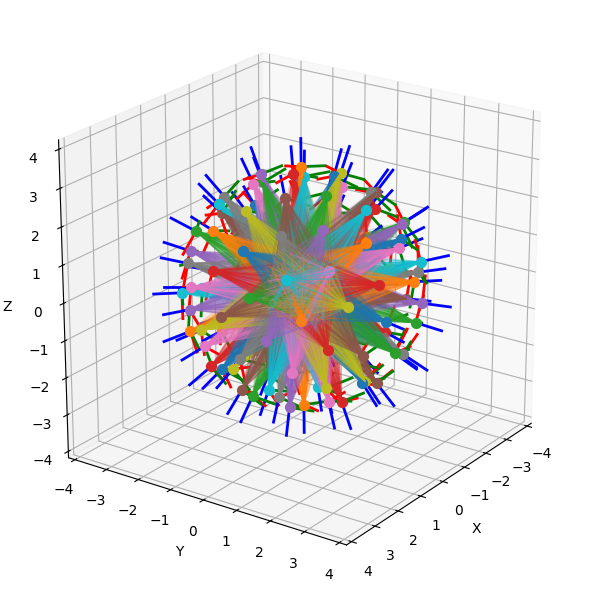

In [11]:

# ---- Optional: plot the world and selected camera ----
if show_world:
    try:
        world = load_world(world_json_path)
        cam = cam
        plot_world(
            world,
            cameras=cam,
            cam_indices='all',
            draw_rays=True,
            ray_mode="lines",
            rays_per_pose=100,
            samples_deterministic=False,
            ray_alpha=0.25,
            samples_alpha=0.1,
            shape_edge_alpha=1.0,
            shape_face_alpha=0.6,
            set_labels=False,
        )
        plt.show()
    except Exception as e:
        print("World plot skipped due to error:", e)


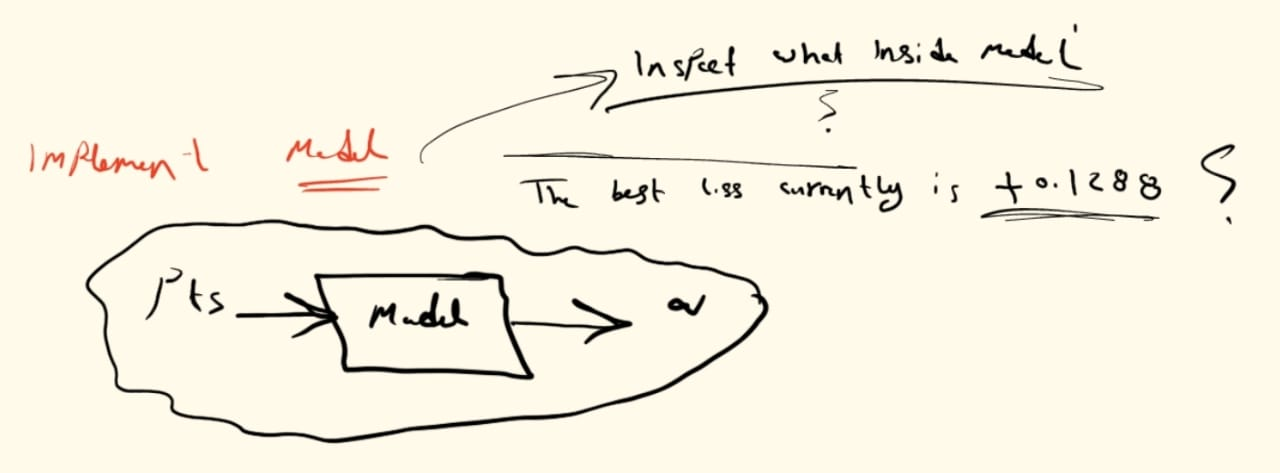

In [12]:
class Tiny_Nerf(Module):
  def __init__(self, in_features = 3, out_features = 1, *args, **kwargs):
    super().__init__(*args, **kwargs)
    self.in_features = in_features # point (x, y, z)
    self.out_features = out_features # sigma scalar
    self.layers = Sequential(Linear(self.in_features, 64),
                             nn.ReLU(),
                             Linear(64, 64),
                             nn.ReLU(),
                             Linear(64, 64),
                             nn.ReLU(),
                             Linear(64, self.out_features),
                            #  Softplus()
                             nn.ReLU()
                             )
  def forward(self, x):
    return self.layers(x).squeeze(-1)
  



In [13]:
                # try +0.3 to +0.7; start with +0.5


In [14]:
TEST = True
if TEST:
  C_true, delta, pts = get_batch_rays(debug=False)
  model = Tiny_Nerf()
  print(model.parameters)

  print(f"pts shape: {pts.shape}")
  print(f"min pts: {torch.min(pts)}    max pts: {torch.max(pts)}")
  sigma = model(pts)
  print(f"sigma shape: {sigma.shape}")
  C_hat = nerf_opacity(sigma, delta, full_output=False)
  # C_hat = compute_opacity_simple(sigma, delta)
  print(f"C_hat shape: {C_hat.shape}")
  print(f"C_true shape: {C_true.shape}")
  # print(C_hat)
  print(f"MSE Loss: {mse_loss(C_hat, C_true):+.04f}")



  # with torch.no_grad():
  #   last = model.layers[6]                 # Linear(64 -> 1)
  #   last.bias.add_(0.5)    

  # probe = LayerProbe(
  #     capture="both",
  #     bins=64,
  #     history_max=3,
  #     print_every=0,
  #     max_elems=250_000,         # <- key for big tensors
  #     sample_mode="uniform",     # or "random"
  #     handle_tuple_outputs=False # set True if your modules return (y, aux,...)
  # )
  # probe.register_on(model)               # hooks leafs; root too if single-module

  probe = LayerProbe(capture="both", history_max=1, bins=32, max_elems=200_000)
  def pred(name, m):
      return name in ("layers.6", "layers.7")
  probe.register_on(model, predicate=pred)

  # _ = model(pts)
  # print(probe.table())
  # probe.plot_hist("layers.2:Linear", which="input")

<bound method Module.parameters of Tiny_Nerf(
  (layers): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): ReLU()
  )
)>
pts shape: torch.Size([100, 1024, 40, 3])
min pts: -1.245908498764038    max pts: 1.212310552597046
sigma shape: torch.Size([100, 1024, 40])
C_hat shape: torch.Size([100, 1024])
C_true shape: torch.Size([100, 1024])
MSE Loss: +0.1524


In [15]:
# learning parameters
LR = 0.1
EPOCHS = 10

In [16]:
optimizer = SGD(model.parameters(), lr=LR)
loss_history = []
for epoch in range(EPOCHS):
  optimizer.zero_grad()
  C_true, delta, pts = get_batch_rays()
  sigma = model(pts)
  C_hat = nerf_opacity(sigma, delta, full_output=False)
  loss = mse_loss(C_hat, C_true)
  print(f"Loss epoch at {epoch:02d}: {loss:+.04f}")
  loss_history.append(loss.item())
  loss.backward()
  optimizer.step()

Loss epoch at 00: +0.1544
Loss epoch at 01: +0.1563
Loss epoch at 02: +0.1544
Loss epoch at 03: +0.1537
Loss epoch at 04: +0.1535
Loss epoch at 05: +0.1521
Loss epoch at 06: +0.1533
Loss epoch at 07: +0.1558
Loss epoch at 08: +0.1543
Loss epoch at 09: +0.1541


In [17]:
# print(probe.table())
# probe.plot_hist("layers.2:Linear", which="input")

_ = model(pts[..., ::4, :])  # fewer samples per ray

print(probe.table())
print(probe.keys())  # see exact tags for plotting

layers.6:Linear              [output] shape=(100, 1024, 10, 1) min=-0.1225 p5=-0.0997 mean=-0.0792 std=+0.0122 p95=-0.0605 max=-0.0453 zero=  0.0% nan= 0.0% inf= 0.0%
layers.7:ReLU                [output] shape=(100, 1024, 10, 1) min=+0.0000 p5=+0.0000 mean=+0.0000 std=+0.0000 p95=+0.0000 max=+0.0000 zero=100.0% nan= 0.0% inf= 0.0%
['layers.6:Linear', 'layers.7:ReLU']


In [18]:
raise

RuntimeError: No active exception to reraise

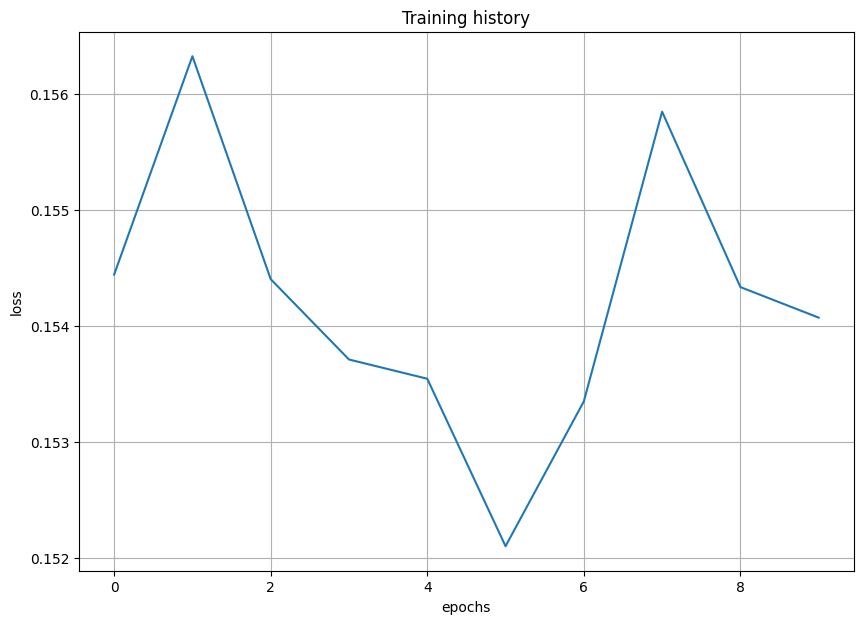

: 

In [ ]:
plt.figure(figsize=[10, 7])
plt.plot(loss_history)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title("Training history")
plt.grid()

In [ ]:
model.eval()
idx_render = 0
H_render = H_wc[idx_render]
cam_render = Camera(H_render)
O, D= cam_render.get_rays()
print(O.shape)
t, delta, pts = cam_render.sample_along_rays(O, D, rng=rng)
sigma = model(pts)
img_flat = nerf_opacity(sigma, delta, full_output=False)
print(img_flat.shape)

torch.Size([307200, 3])


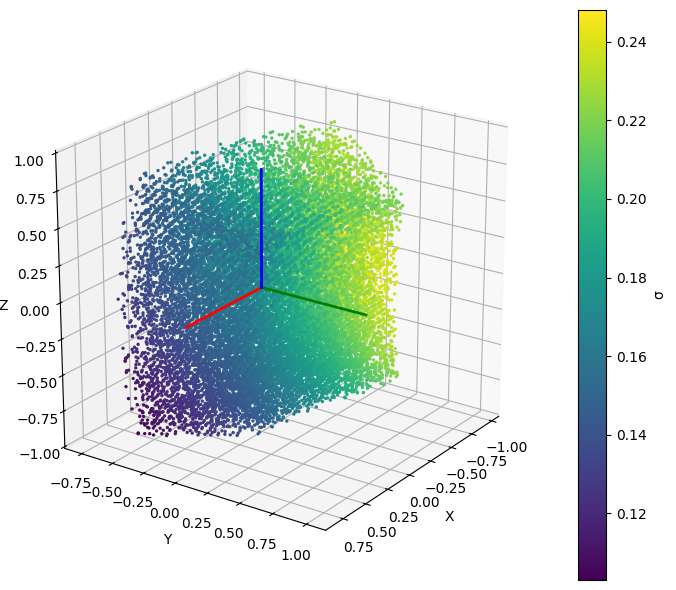

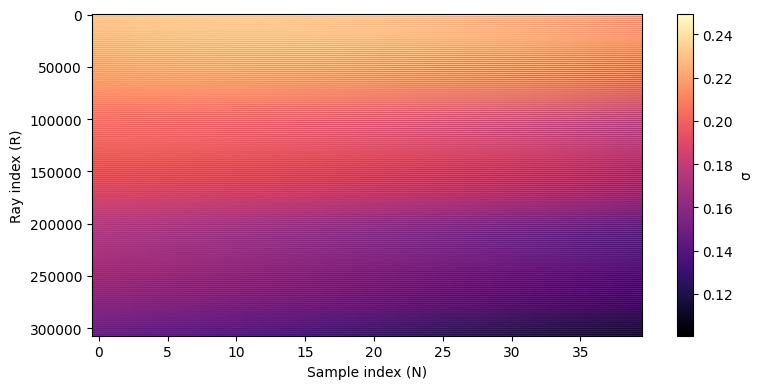

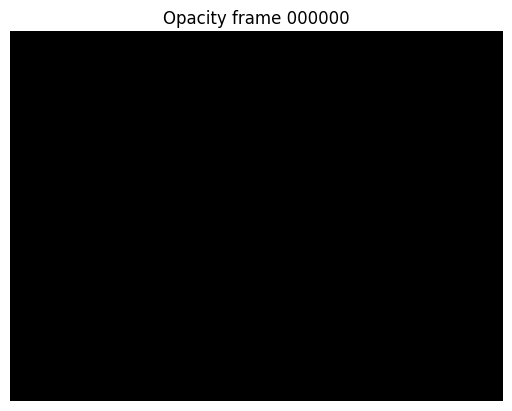

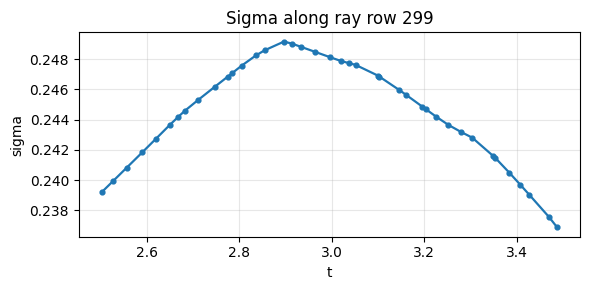

Picked row: 299


In [ ]:
# Convert to numpy for viz helpers
t_np = t.detach().cpu().numpy()
sigma_np = sigma.detach().cpu().numpy()

# Downsample for scatter to keep it light
R = H * W
N = t_np.shape[-1]
stride_r = max(1, R // 5000)   # adjust if you want fewer/more points
stride_n = max(1, N // 16)

X = pts
if X.ndim == 3 and X.shape[-1] == 3 and X.shape[:2] == sigma.shape:
    X_np = X.detach().cpu().numpy()
    X_sub = X_np[::stride_r, ::stride_n, :]      # (R', N', 3)
    sigma_sub = sigma_np[::stride_r, ::stride_n] # (R', N')
    viz_sigma_scatter(X_sub, sigma_sub)          # no flattening
    plt.show()
else:
    print("Skipping scatter: X shape is not (R,N,3) matching sigma (R,N).")


# Heatmap over sigma (expects (R, N))
viz_sigma_heatmap(sigma_np)
plt.show()

# Opacity mask render
rnd = Renderer(BinaryRenderCfg(threshold=0.5))
fig, ax, _ = rnd.binary(
    C = img_flat.view(H, W).detach().cpu().numpy(),
    intr=Intrinsics(**CFG.intrinsics.__dict__),
    title=f"Opacity frame {frame_ids[idx]}",
    save_path=str(scene_dir / f"opacity_{frame_ids[idx]}.png"),
)
plt.show()

# Example: pick a nonzero sigma row to inspect
r = plot_nonzero_sigma_row(t, sigma, strategy="max", mark_nonzero=True)
print(f"Picked row: {r}")